<a href="https://colab.research.google.com/github/eduzegarra/grade_01/blob/main/Ollas_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


---

# EXAMPLE OF DATA PROCESSING AND ANALYSIS USING PYTHON IN COLAB

---

## Data from Villa Maria del Triunfo district in Lima

Connect to Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Check you have 4 files with geographic data your in Drive's directory

In [2]:
import os
os.chdir('/content/drive/MyDrive/Ollas')
!ls

vmt_boundary.gpkg  vmt_census.gpkg  vmt_comedores.gpkg	vmt_ollas_dist.gpkg


Import modules to use from Python

In [3]:
import geopandas as gpd
import folium
import matplotlib.pyplot as plt

Retrieve files as "variables" using GeoPandas (files with geographic data in gpkg formar of QGis)

In [4]:
# Each file is assigned to a variable gdf_... (gdf: GeoDataFrama)
gdf_census = gpd.read_file("vmt_census.gpkg")
gdf_comedores = gpd.read_file("vmt_comedores.gpkg")
gdf_ollas = gpd.read_file("vmt_ollas_dist.gpkg")
gdf_vmt = gpd.read_file("vmt_boundary.gpkg")

**Step 1. Exploring content and features of data in files**

In [5]:
gdf_census.head()

,id,t_poblacion_sum,t_agua_mean,t_piso_mean,d_comedor,slope_num,altitude_num,geometry
0,12626,3580.0,0.017262,0.006002,0.000000,2.421652,168.0,"MULTIPOLYGON (((286553.74 8655520.172, 286533...."
1,12627,2252.0,0.050171,0.001736,96.295911,0.229456,134.0,"MULTIPOLYGON (((286582.777 8655495.309, 286712..."
2,12835,2750.0,0.122459,0.136898,0.000000,5.492950,275.0,"MULTIPOLYGON (((286934.004 8656726.638, 286931..."
3,12836,2023.0,0.116582,0.169882,0.000000,3.557562,294.0,"MULTIPOLYGON (((286854.872 8656297.503, 286869..."
4,12837,2921.0,0.135123,0.144886,0.000000,3.583085,265.0,"MULTIPOLYGON (((286850.242 8655921.846, 286850..."


In [6]:
gdf_census.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   id               325 non-null    int64   
 1   t_poblacion_sum  294 non-null    float64 
 2   t_agua_mean      294 non-null    float64 
 3   t_piso_mean      294 non-null    float64 
 4   d_comedor        325 non-null    float64 
 5   slope_num        325 non-null    float64 
 6   altitude_num     325 non-null    float64 
 7   geometry         325 non-null    geometry
dtypes: float64(6), geometry(1), int64(1)
memory usage: 20.4 KB


In [7]:
## Census data was generated per each Cell (these are to be the units of analysis)
gdf_census.describe()

,id,t_poblacion_sum,t_agua_mean,t_piso_mean,d_comedor,slope_num,altitude_num
count,325.000000,294.00000,294.000000,294.000000,325.000000,325.000000,325.000000
mean,14694.633846,1361.37415,0.309885,0.116700,190.800725,2.882285,290.092308
std,1071.842243,1049.32987,0.304583,0.126198,416.820674,2.087194,141.718588
min,12626.000000,30.00000,0.000000,0.000000,0.000000,0.127279,68.000000
25%,13894.000000,400.25000,0.067275,0.025019,0.000000,1.188886,181.000000
50%,14743.000000,1288.50000,0.153801,0.078181,22.009445,2.281282,259.000000
75%,15593.000000,2026.00000,0.530391,0.162874,168.280320,4.239086,356.000000
max,17292.000000,4784.00000,1.000000,0.709104,2317.959504,11.136932,785.000000


<Axes: >

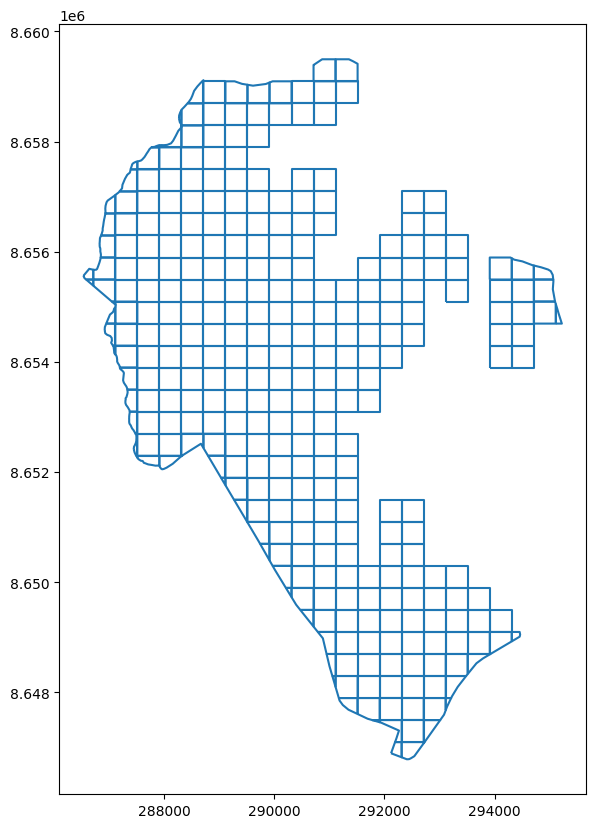

In [8]:
### plotting the mesh of 'gdf_census' using plot()
gdf_census.boundary.plot(figsize=(20,10))

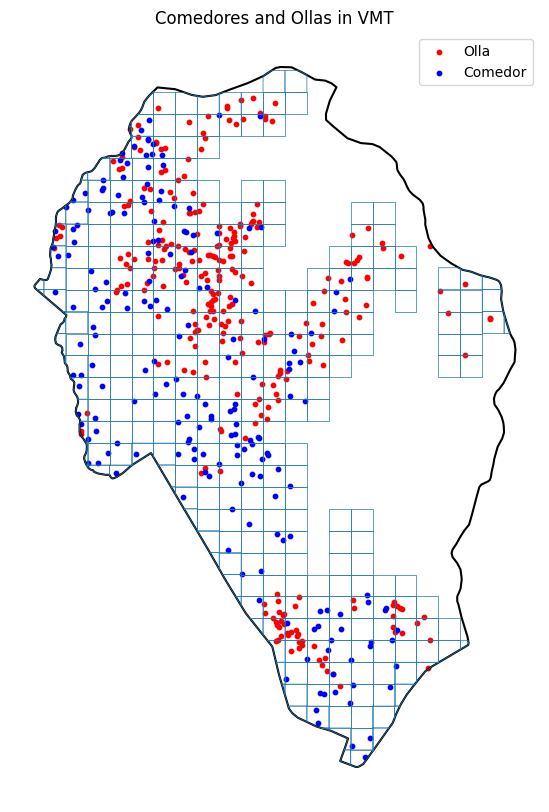

In [9]:
# Looking at the location of Comedores and Ollas
axis=gdf_vmt.boundary.plot(figsize=(20,10), color='black')
gdf_census.boundary.plot(ax=axis, linewidth=0.5)
axis.set_axis_off()
gdf_ollas.plot(color='red', ax=axis, markersize=10, label="Olla")
gdf_comedores.plot(color='blue', ax=axis, markersize=10, label="Comedor")
plt.title("Comedores and Ollas in VMT")
plt.legend()
plt.show()

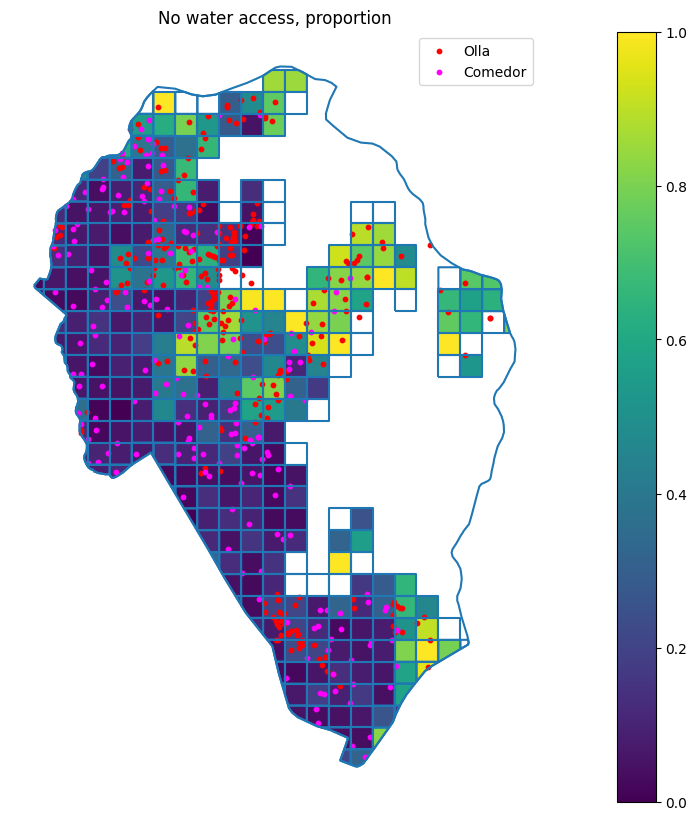

In [10]:
## Looking at water access and Ollas/Comedores location
axis=gdf_vmt.boundary.plot(figsize=(20,10))
gdf_census.boundary.plot(ax=axis)
axis.set_axis_off()
gdf_census.plot(column='t_agua_mean', ax=axis, legend=True)
plt.title("No water access, proportion")
gdf_ollas.plot(color='red', ax=axis, markersize=10, label="Olla")
gdf_comedores.plot(color='magenta', ax=axis, markersize=10, label="Comedor")
plt.legend()
plt.show()

**Caution:! notice that there are some empty cells, with no data**

In [11]:
# How many NaN cells (no Census data) are in the Mesh?
(gdf_census.isna()==True).sum()

,0
id,0
t_poblacion_sum,31
t_agua_mean,31
t_piso_mean,31
d_comedor,0
slope_num,0
altitude_num,0
geometry,0


# Step 2. Cleaning and relating data

In [12]:
## we drop observations with Nan values (no Census Data)
census_clean=gdf_census.dropna()

In [13]:
census_clean.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 294 entries, 0 to 324
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   id               294 non-null    int64   
 1   t_poblacion_sum  294 non-null    float64 
 2   t_agua_mean      294 non-null    float64 
 3   t_piso_mean      294 non-null    float64 
 4   d_comedor        294 non-null    float64 
 5   slope_num        294 non-null    float64 
 6   altitude_num     294 non-null    float64 
 7   geometry         294 non-null    geometry
dtypes: float64(6), geometry(1), int64(1)
memory usage: 20.7 KB


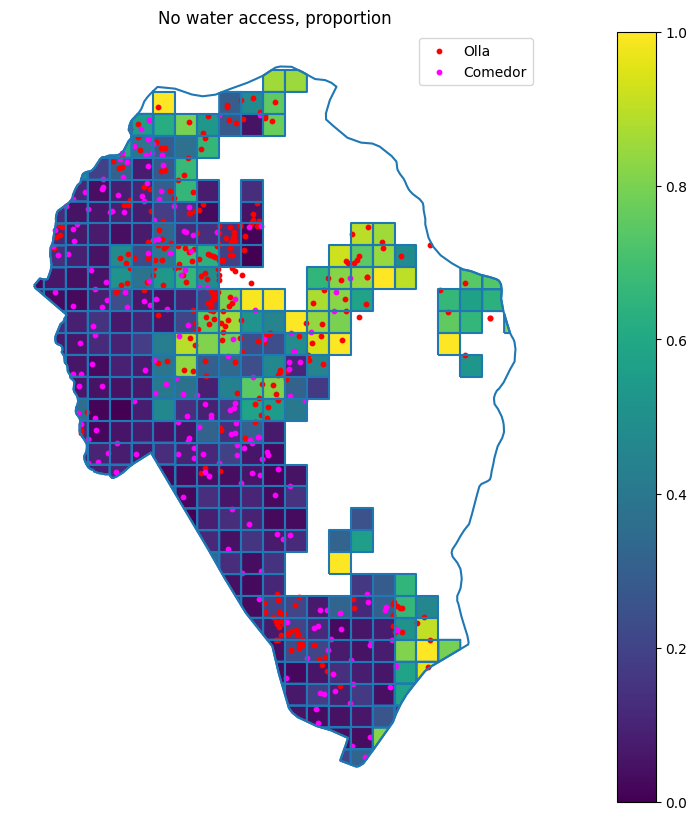

In [14]:
# Check Census Mesh have data on all Cells
axis=gdf_vmt.boundary.plot(figsize=(20,10))
census_clean.boundary.plot(ax=axis)
axis.set_axis_off()
census_clean.plot(column='t_agua_mean', ax=axis, legend=True)
plt.title("No water access, proportion")
gdf_ollas.plot(color='red', ax=axis, markersize=10, label="Olla")
gdf_comedores.plot(color='magenta', ax=axis, markersize=10, label="Comedor")
plt.legend()
plt.show()

In [15]:
## Now look at file 'Ollas'
gdf_ollas.describe()

,n_benef,codigo,_distance
count,290.000000,290.000000,290.000000
mean,68.517241,1866.044828,488.169867
std,28.144733,200.368574,486.089075
min,16.000000,826.000000,5.828028
25%,50.000000,1821.250000,249.442723
50%,64.500000,1894.500000,368.233483
75%,85.000000,1966.750000,560.478096
max,196.000000,2041.000000,3904.510950


In [16]:
gdf_ollas.columns

Index(['distrito', 'nombre_de', 'direccion', 'codigo_ol', 'estado', 'n_benef',
       'codigo', '_distance', '_manual', 'geometry'],
      dtype='object')

File with 290 Ollas, for which we have walking distance ('_distance') to nearest Comedor.  We want to relate these values to the Census data

Task: to assign values in Ollas to Census Data Mesh (3 steps)

In [17]:
# Step 1 Run a "spatial join" between Ollas and Census Mesh to get the "id" variable from Census assigned to each Olla
joined=gpd.sjoin(gdf_ollas, census_clean, how="left", predicate="intersects")[['codigo_ol','id','_distance']]

In [18]:
joined.head(10)

,codigo_ol,id,_distance
0,X1501230064,16460.0,969.931599
1,X1501230116,16458.0,733.075794
2,X1501230051,NaN,3633.704915
3,X1501230040,NaN,3054.537097
4,X1501230083,NaN,3047.029641
5,X1501230084,16656.0,3090.870132
6,X1501230055,16866.0,2730.607608
7,X1501230036,NaN,3904.510950
8,X1501230087,16655.0,1833.827631
9,X1501430336,15613.0,317.320054


In [19]:
## There are 10 Ollas not overlapping with the Clean Census Mesh
joined.id.isna().sum()

np.int64(10)

In [20]:
## Eliminate those observations from Ollas file as will not be useful
joined=joined.dropna()

In [21]:
joined.shape

(280, 3)

In [22]:
joined.head()

,codigo_ol,id,_distance
0,X1501230064,16460.0,969.931599
1,X1501230116,16458.0,733.075794
5,X1501230084,16656.0,3090.870132
6,X1501230055,16866.0,2730.607608
8,X1501230087,16655.0,1833.827631


In [23]:
# 2.2. Calculate number of Ollas per Cell and mean walking distance to nearest Comedor (Cells with Olla)
ollas_summ=joined.rename(columns={'codigo_ol':'ollas_count'}).groupby('id').agg({'ollas_count':'count','_distance':'mean'})

In [24]:
ollas_summ.ollas_count.sum()

np.int64(280)

In [25]:
# 2.3. After calculating number of ollas and mean walking distance, we merge that with Census cells, assigning values from Ollas to the Census dataframe
census_clean=census_clean.merge(ollas_summ, on='id', how='left')

In [26]:
census_clean.describe()

,id,t_poblacion_sum,t_agua_mean,t_piso_mean,d_comedor,slope_num,altitude_num,ollas_count,_distance
count,294.000000,294.00000,294.000000,294.000000,294.000000,294.000000,294.000000,119.000000,119.000000
mean,14609.571429,1361.37415,0.309885,0.116700,147.566752,2.769761,275.282313,2.352941,491.978787
std,1057.754028,1049.32987,0.304583,0.126198,366.921652,2.032872,129.511837,1.715277,432.334284
min,12626.000000,30.00000,0.000000,0.000000,0.000000,0.127279,68.000000,1.000000,5.828028
25%,13693.250000,400.25000,0.067275,0.025019,0.000000,1.154750,180.250000,1.000000,276.600780
50%,14542.500000,1288.50000,0.153801,0.078181,5.721275,2.209515,250.500000,2.000000,390.477985
75%,15394.500000,2026.00000,0.530391,0.162874,114.536675,4.118173,336.750000,3.000000,537.545562
max,17292.000000,4784.00000,1.000000,0.709104,2317.959504,11.136932,785.000000,10.000000,3090.870132


We have 325 cells, 294 with census data, and Ollas are located in 119 cells.  We need to fill the distance variable for the cells without ollas

In [27]:
## Replace values of cells without Ollas with original "distance to nearest Comedor" d_comedor (is a linear or Euclidean distance)
census_clean.loc[census_clean['_distance'].isna(),'_distance']=census_clean.d_comedor

In [28]:
## Replacing values for cells without Olla with 'ollas_count'==0
census_clean.loc[census_clean.ollas_count.isna(),'ollas_count']=0

In [29]:
### Here a look a the almost final Census database
census_clean.describe()

,id,t_poblacion_sum,t_agua_mean,t_piso_mean,d_comedor,slope_num,altitude_num,ollas_count,_distance
count,294.000000,294.00000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000
mean,14609.571429,1361.37415,0.309885,0.116700,147.566752,2.769761,275.282313,0.952381,294.945711
std,1057.754028,1049.32987,0.304583,0.126198,366.921652,2.032872,129.511837,1.588497,445.371874
min,12626.000000,30.00000,0.000000,0.000000,0.000000,0.127279,68.000000,0.000000,0.000000
25%,13693.250000,400.25000,0.067275,0.025019,0.000000,1.154750,180.250000,0.000000,0.000000
50%,14542.500000,1288.50000,0.153801,0.078181,5.721275,2.209515,250.500000,0.000000,160.461748
75%,15394.500000,2026.00000,0.530391,0.162874,114.536675,4.118173,336.750000,2.000000,399.863511
max,17292.000000,4784.00000,1.000000,0.709104,2317.959504,11.136932,785.000000,10.000000,3090.870132


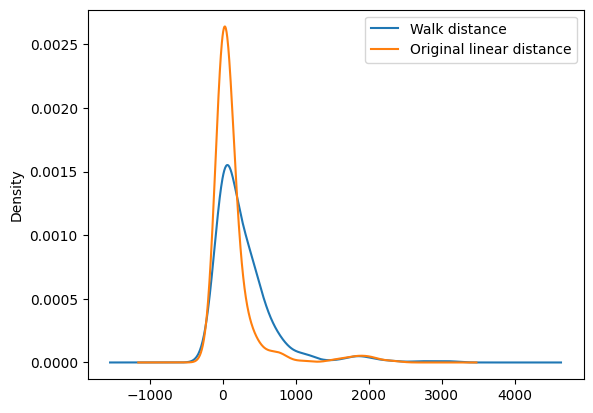

In [30]:
## Look at the distribution of d_comedor versus _distance
axis=census_clean._distance.plot(kind='kde')
census_clean.d_comedor.plot(kind='kde', ax=axis)
plt.legend(['Walk distance','Original linear distance'])
plt.show()

In [31]:
## We want to see descriptive statistics for cells with and without Ollas
## First create a new variable that identifies cells with/without Ollas
census_clean['has_olla']=0

In [32]:
## Now assign 1 to cells with 1 or more Ollas
census_clean.loc[census_clean.ollas_count>0,'has_olla']=1

In [33]:
census_clean.describe()

,id,t_poblacion_sum,t_agua_mean,t_piso_mean,d_comedor,slope_num,altitude_num,ollas_count,_distance,has_olla
count,294.000000,294.00000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000
mean,14609.571429,1361.37415,0.309885,0.116700,147.566752,2.769761,275.282313,0.952381,294.945711,0.404762
std,1057.754028,1049.32987,0.304583,0.126198,366.921652,2.032872,129.511837,1.588497,445.371874,0.491683
min,12626.000000,30.00000,0.000000,0.000000,0.000000,0.127279,68.000000,0.000000,0.000000,0.000000
25%,13693.250000,400.25000,0.067275,0.025019,0.000000,1.154750,180.250000,0.000000,0.000000,0.000000
50%,14542.500000,1288.50000,0.153801,0.078181,5.721275,2.209515,250.500000,0.000000,160.461748,0.000000
75%,15394.500000,2026.00000,0.530391,0.162874,114.536675,4.118173,336.750000,2.000000,399.863511,1.000000
max,17292.000000,4784.00000,1.000000,0.709104,2317.959504,11.136932,785.000000,10.000000,3090.870132,1.000000


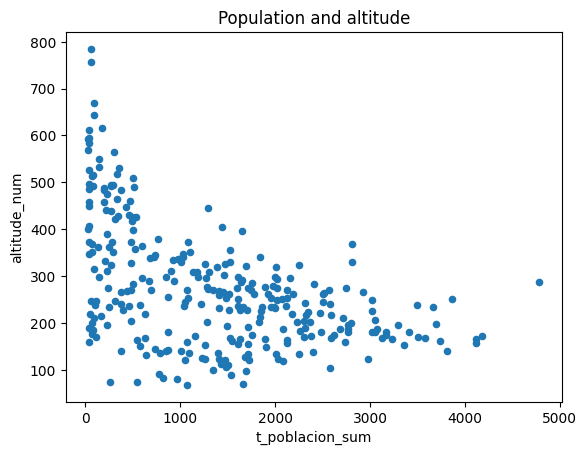

In [34]:
## Check some bivariate relations for some variables
census_clean.plot.scatter(x='t_poblacion_sum',y='altitude_num')
plt.title("Population and altitude")
plt.show()

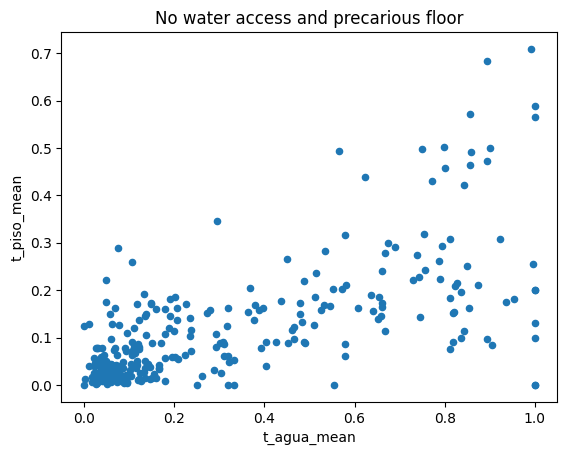

In [35]:
census_clean.plot.scatter(x='t_agua_mean',y='t_piso_mean')
plt.title("No water access and precarious floor")
plt.show()

In [36]:
### Descriptive statistics for Cells with/without Olla
descrip1=census_clean.groupby('has_olla').agg({'t_poblacion_sum':'mean',
 'd_comedor':'mean',
 'altitude_num':'mean',
 '_distance':'mean'
 })
descrip2=census_clean.groupby('has_olla').agg({'t_agua_mean':'mean',
 't_piso_mean':'mean', 'slope_num':'mean',
 })

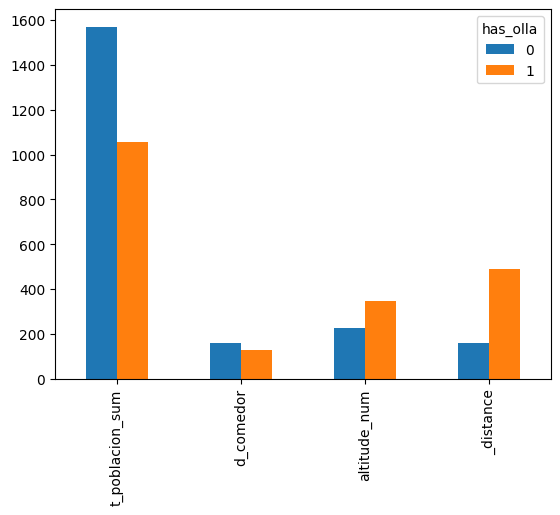

In [37]:
descrip1.transpose().plot.bar()
plt.show()

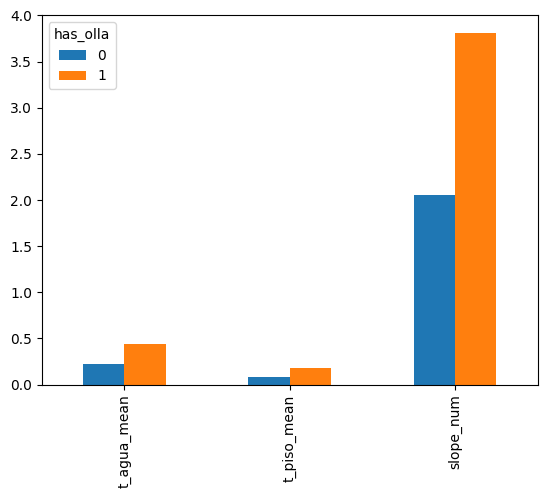

In [38]:
descrip2.transpose().plot.bar()
plt.show()

### Step 3: Modeling

In [39]:
## We can estimate a PROBIT MODEL of the probability of each cell having 1 or more Ollas
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import numpy as np

In [40]:
## It is a good practice to transform some variables to logs (better statistical behavios)
census_clean['log_pob']=np.log(np.maximum(census_clean["t_poblacion_sum"], 1))
census_clean['log_altitude']=np.log(np.maximum(census_clean["altitude_num"], 1))
census_clean['log_distance']=np.log(np.maximum(census_clean["_distance"], 1))

In [41]:
formula = (
    "has_olla ~ log_distance + "
    "t_agua_mean + "
    "t_piso_mean + "
    "slope_num + "
    "log_altitude+ "
    "log_pob"
)

In [42]:
probit_model = smf.probit(formula=formula, data=census_clean).fit(cov_type="HC1")
print(probit_model.summary())

Optimization terminated successfully.
         Current function value: 0.290146
         Iterations 8
                          Probit Regression Results                           
Dep. Variable:               has_olla   No. Observations:                  294
Model:                         Probit   Df Residuals:                      287
Method:                           MLE   Df Model:                            6
Date:                Mon, 14 Sep 2026   Pseudo R-squ.:                  0.5701
Time:                        17:37:09   Log-Likelihood:                -85.303
converged:                       True   LL-Null:                       -198.42
Covariance Type:                  HC1   LLR p-value:                 4.875e-46
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -14.1718      3.002     -4.720      0.000     -20.056      -8.287
log_distance     0.7047

In [43]:
margeff = probit_model.get_margeff(at="overall", method="dydx")
print("\n" + "=" * 60)
print("AVERAGE MARGINAL EFFECTS (dy/dx)")
print("=" * 60)
print(margeff.summary())


AVERAGE MARGINAL EFFECTS (dy/dx)
       Probit Marginal Effects       
Dep. Variable:               has_olla
Method:                          dydx
At:                           overall
                  dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
log_distance     0.1166      0.016      7.076      0.000       0.084       0.149
t_agua_mean      0.0134      0.074      0.180      0.857      -0.132       0.159
t_piso_mean      0.3316      0.189      1.753      0.080      -0.039       0.702
slope_num        0.0210      0.012      1.787      0.074      -0.002       0.044
log_altitude     0.1517      0.061      2.478      0.013       0.032       0.272
log_pob          0.1216      0.015      7.923      0.000       0.092       0.152


# New SectionStep 4: Interpreting the model

**Query to Gemini:** Give an intepretation of these marginal effects

**Response**:
Average Marginal Effects (dy/dx)
In a Probit model, marginal effects tell us how a one-unit change in an independent variable affects the probability of the dependent variable (has_olla) being 1 (i.e., the probability of a cell having one or more Ollas). These effects are calculated at the 'overall' average of all other variables.

Here's what your results indicate:

**log_distance** (log of distance to nearest comedor): A one-unit increase in the log of the walking distance to the nearest 'Comedor' is associated with an 11.66 percentage point increase in the probability of a cell having an Olla. This is a statistically significant effect (P>|z| = 0.000). This suggests that Ollas are more likely to be found further away from existing 'Comedores', possibly filling a gap in food provision.

**t_agua_mean** (proportion of households without water access): The effect of t_agua_mean is not statistically significant (P>|z| = 0.857), meaning we cannot confidently say that changes in the proportion of households without water access significantly impact the probability of a cell having an Olla, based on this model.

**t_piso_mean** (proportion of households with precarious flooring): A one-unit increase in the proportion of households with precarious flooring is associated with a 33.16 percentage point increase in the probability of a cell having an Olla. This effect is marginally statistically significant (P>|z| = 0.080), suggesting that areas with poorer housing conditions are more likely to have Ollas.

**slope_num** (slope of the terrain): A one-unit increase in the slope of the terrain is associated with a 2.10 percentage point increase in the probability of a cell having an Olla. This effect is also marginally statistically significant (P>|z| = 0.074), indicating that Ollas might be slightly more common in areas with steeper slopes, which could correspond to more challenging and potentially underserved areas.

**log_altitude** (log of altitude): A one-unit increase in the log of altitude is associated with a 15.17 percentage point increase in the probability of a cell having an Olla. This is a statistically significant effect (P>|z| = 0.013). This suggests that Ollas are more likely to be found at higher altitudes, which are often more remote and less accessible.

**log_pob** (log of total population): A one-unit increase in the log of the total population is associated with a 12.16 percentage point increase in the probability of a cell having an Olla. This is a highly statistically significant effect (P>|z| = 0.000), indicating that more populated areas are more likely to have Ollas.

**In summary, the model suggests that cells are more likely to have Ollas if they are located further from existing 'Comedores', in areas with a higher proportion of precarious flooring, steeper slopes, higher altitudes, and greater populations. This aligns with the idea that Ollas often emerge to address food insecurity in vulnerable and underserved communities.**

# Step 5. Assessing the quality of the Model

In [44]:
import numpy as np
census_clean["pred_prob"] = probit_model.predict()

# Classification threshold (using empirical sample proportion)
threshold = census_clean["has_olla"].mean()
census_clean["pred_binary"] = (census_clean["pred_prob"] >= threshold).astype(int)

auc = roc_auc_score(census_clean["has_olla"], census_clean["pred_prob"])
cm = confusion_matrix(census_clean["has_olla"], census_clean["pred_binary"])

print("\n" + "=" * 60)
print("MODEL DIAGNOSTICS")
print("=" * 60)
print(f"Sample Size (N)       : {len(census_clean)}")
print(f"Olla Presence Cells   : {census_clean['has_olla'].sum()} ({census_clean['has_olla'].mean():.2%})")
print(f"Pseudo R-squared (McF): {probit_model.prsquared:.4f}")
print(f"Log-Likelihood        : {probit_model.llf:.2f}")
print(f"ROC-AUC Score         : {auc:.4f}")
print("\nConfusion Matrix (Threshold = {:.2f}):".format(threshold))
print(cm)
print("\nClassification Report:")
print(classification_report(census_clean["has_olla"], census_clean["pred_binary"]))


MODEL DIAGNOSTICS
Sample Size (N)       : 294
Olla Presence Cells   : 119 (40.48%)
Pseudo R-squared (McF): 0.5701
Log-Likelihood        : -85.30
ROC-AUC Score         : 0.9471

Confusion Matrix (Threshold = 0.40):
[[145  30]
 [ 10 109]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.83      0.88       175
           1       0.78      0.92      0.84       119

    accuracy                           0.86       294
   macro avg       0.86      0.87      0.86       294
weighted avg       0.87      0.86      0.87       294



**Gemini Query:** Explain Model Diagnostics, Confusion Matrix and Classification Report


**Response**

Model Diagnostics Overview

The model diagnostics provide a comprehensive look at how well your Probit model performed in predicting whether a cell has_olla (1 or more Ollas) or not (no Ollas). Here's what each part tells us:

**Sample Size (N)**: This is the total number of observations (cells) used in your model, which is 294.

**Olla Presence Cells**: This tells us how many cells in your dataset actually have one or more Ollas, and its proportion (40.48% in this case).
Pseudo R-squared (McF): This is a measure of how well the model explains the variability in the dependent variable (whether a cell has an Olla). A value of 0.5701 indicates that about 57% of the variation in Olla presence can be explained by your model's independent variables. Higher values generally mean a better fit.

**Log-Likelihood**: This is a measure of how likely your observed data is given your model. Higher values (closer to zero) indicate a better fit.

**ROC-AUC Score**: The Receiver Operating Characteristic - Area Under the Curve (ROC-AUC) score is a measure of the model's ability to distinguish between the two classes (cells with Ollas vs. cells without Ollas). A score of 0.9471 is very good, indicating excellent discrimination capability.

**Confusion Matrix**

The Confusion Matrix helps visualize the performance of a classification model. It shows the number of correct and incorrect predictions made by the model compared to the actual outcomes. The threshold of 0.40 indicates the probability cutoff used to classify a cell as having an Olla (predicted_prob >= 0.40) or not.

Confusion Matrix (Threshold = 0.40):
[[145  30]
 [ 10 109]]

Let's interpret this:

True Negatives (Top-Left, 145): The model correctly predicted 145 cells as not having an Olla (actual 0, predicted 0).
False Positives (Top-Right, 30): The model incorrectly predicted 30 cells as having an Olla when they did not (actual 0, predicted 1). These are Type I errors.
False Negatives (Bottom-Left, 10): The model incorrectly predicted 10 cells as not having an Olla when they did (actual 1, predicted 0). These are Type II errors.
True Positives (Bottom-Right, 109): The model correctly predicted 109 cells as having an Olla (actual 1, predicted 1).

**Classification Report**

The Classification Report provides a more detailed breakdown of the model's performance for each class (0 for no Olla presence, 1 for Olla presence) and overall averages.

              precision    recall  f1-score   support

           0       0.94      0.83      0.88       175
           1       0.78      0.92      0.84       119

    accuracy                           0.86       294
   macro avg       0.86      0.87      0.86       294
weighted avg       0.87      0.86      0.87       294
Let's break down the metrics:

Precision: Precision for a class is the ratio of correctly predicted positive observations to the total predicted positive observations. A high precision means a low false positive rate.
For class 0 (no Olla): 0.94 (94% of cells predicted as having no Olla actually had no Olla).
For class 1 (Olla presence): 0.78 (78% of cells predicted as having Olla actually had Olla).

Recall: Recall (also known as sensitivity) for a class is the ratio of correctly predicted positive observations to all observations in the actual class. A high recall means a low false negative rate.
For class 0 (no Olla): 0.83 (83% of actual no-Olla cells were correctly identified).
For class 1 (Olla presence): 0.92 (92% of actual Olla-present cells were correctly identified).
F1-score: The F1-score is the weighted average of

**Precision and Recall.** It tries to find the balance between precision and recall. A high F1-score indicates good performance in both.
For class 0: 0.88
For class 1: 0.84
Support: This is the number of actual occurrences of the class in the specified dataset.
For class 0: 175 observations.
For class 1: 119 observations.

**Overall Metrics:**

Accuracy: This is the proportion of total correct predictions (both true positives and true negatives) across all classes. Your model achieved an accuracy of 0.86, meaning 86% of the predictions were correct.

Macro Avg: This calculates the average of the metrics (precision, recall, f1-score) independently for each class and then takes the unweighted mean. It treats all classes equally.
Macro Avg Precision: 0.86
Macro Avg Recall: 0.87
Macro Avg F1-score: 0.86
Weighted Avg: This calculates the average of the metrics (precision, recall, f1-score) for each class, weighted by their support (the number of instances for each class). This accounts for class imbalance.
Weighted Avg Precision: 0.87
Weighted Avg Recall: 0.86
Weighted Avg F1-score: 0.87
In summary, the model shows strong overall performance with an accuracy of 86%. It performs particularly well in identifying actual Olla presence (high recall for class 1), which is often a critical aspect in such analyses.

### ROC Curve
The Receiver Operating Characteristic (ROC) curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. The curve plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings. The Area Under the Curve (AUC) is a measure of the ability of a classifier to distinguish between classes and is used as a summary of the ROC curve.

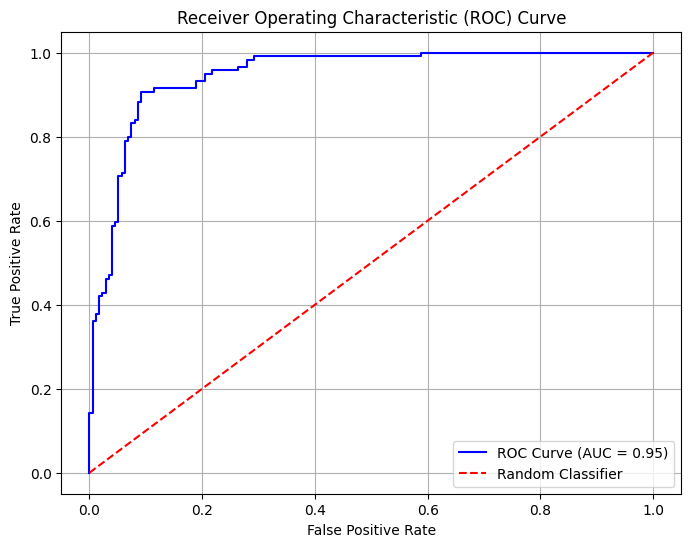

In [45]:
from sklearn.metrics import roc_curve

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(census_clean["has_olla"], census_clean["pred_prob"])

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()